# Estadistica Descriptiva

## Percentiles

* Un percentil responde: *“¿Qué porcentaje de datos está por debajo de cierto valor?”*
* Si estás en el `percentil 90` significa ue tienes un valor mayor al 90% de los datos.
* Los cuartiles son percentiles, los cuales corresponden a:
| Cuartil | Percentil     |
| ------- | ------------- |
| Q1      | 25%           |
| Q2      | 50% (mediana) |
| Q3      | 75%           |
* También existe el `IQR (Interquartile Range)`, que mide la dispersión del "centro" de los datos.
* Es decir, calcularíamos algo como esto: $IQR = Q_3 - Q_1$.
* ***¿Por qué es tan útil?***
  - Ignora extremos.
  - Es robusto ante outliers.
  - Mucho más estable que el rango.
* Por ejemplo, en esta serie de datos `1, 2, 3, 4, 1000`, tendríamos un `Rango` grande y un `IQR` pequeño.
  - Porque el centro de los datos sigue compacto.
* ***Outliers***
  - `Outlier Superior`: $Q_3 + (1.5 \cdot IQR)$
  - `Outlier Inferior`: $Q_1 - (1.5 \cdot IQR)$
* Si un valor está MUY lejos del centro: ***probablemente es un outlier***.
* ***Tipos de Percentiles***
* `Mediana`: implica dividir la distribución en 2 partes.
* `Terciles`: implica dividir la distribución en 3 partes.
* `Cuartiles`: implica dividir la distribución en 4 partes.
* `Quintiles`:  implica dividir la distribución en 5 partes.
* `Deciles`: implica dividir la distribución en 10 partes.
* `Percentiles`: implica dividir la distribución en 100 partes.

### Ejemplos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Fijamos los valores
np.random.seed(0)
alturas = np.random.normal(loc=1.75, scale=0.15, size=100000)

### Activamos que calcule todos los cuartiles
cuartiles = np.quantile(alturas, [0,1/4,2/4,3/4,1])
print("Cuartiles:", cuartiles)

### Terciles
terciles =  np.quantile(alturas, [0,1/3,2/3,1])
print("Terciles:", terciles)

Cuartiles: [1.02218235 1.64970375 1.75025803 1.85101581 2.38626579]
Terciles: [1.02218235 1.6862861  1.81477558 2.38626579]


In [9]:
### Semilla para reproducibilidad
np.random.seed(42)

### 1. Distribución normal
normal = np.random.normal(
    loc=50,      # media
    scale=10,    # desviación estándar
    size=1000
)

### 2. Sesgada a la derecha (cola hacia valores grandes)
sesgo_derecha = np.random.exponential(
    scale=10,
    size=1000
)

### 3. Sesgada a la izquierda (invertimos una exponencial)
sesgo_izquierda = 100 - np.random.exponential(
    scale=10,
    size=1000
)

### Lista de datos
distribuciones = [
    ("Normal", normal, "steelblue"),
    ("Sesgo derecha", sesgo_derecha, "orange"),
    ("Sesgo izquierda", sesgo_izquierda, "green")
]

### Cuartiles
cortes = [0.25, 0.50, 0.75]

### Gráfica con Matplot

* `plt.subplots()` nos da `fig` y `axes`, es decir, la hoja en blanco y los ejes para graficar cada una.
* Vamos a graficar 3 filas, no 3 columnas.
* `axes` es un arreglo con 3 objetos `Axes`, es decir, cada uno es una gráfica independiente.
* Establecemos `10 de ancho` con `12 de alto`.
* `sharex=True`: *"todas las gráficas compartirán el mismo eje X"*.
* Entonces:
  - Los mismos límites.
  - La misma escala.
  - Las mismas marcas del eje.
* Sin eso, `matplotlib` ajusta cada histograma individualmente y la comparación visual se vuelve engañosa.
* Dada la estructura que creamos, tenemos que recorrer de esta forma `for ax, (titulo, datos, color) in zip(axes, distribuciones)`.
* Lo malo de usar `matplotlib` es definir los `bins` --> `ax.hist(datos, bins=30, color=color, alpha=0.7)`.
* `axvline` significa: ***axis vertical line***, literalmente hace un gráfica `x=cuartil_i`.
* `ax.text` es para agregar un texto en una zona indicada de la gráfica.

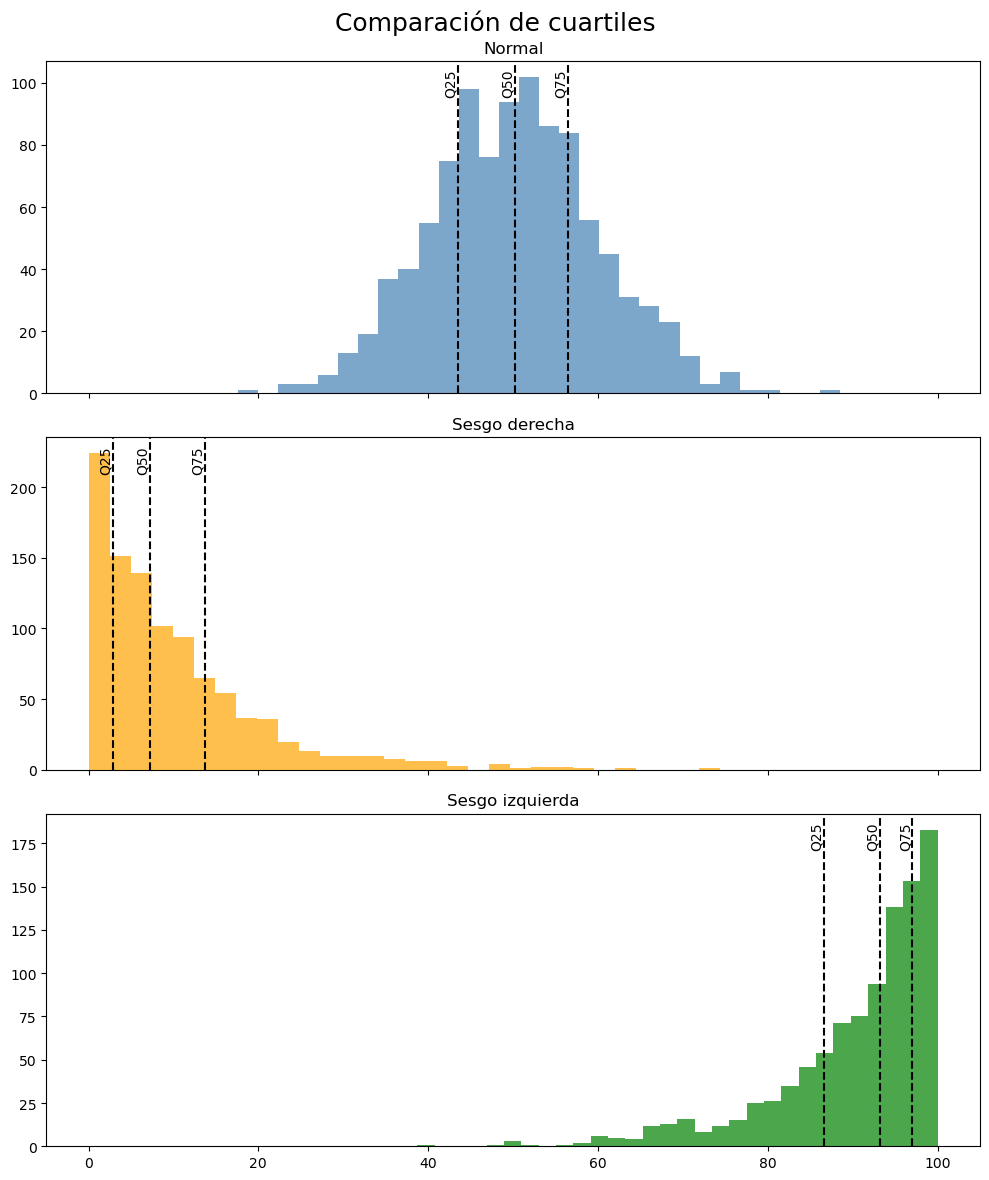

In [7]:
# Subplots alineados
fig, axes = plt.subplots(nrows=3, figsize=(10, 12), sharex=True)

for ax, (titulo, datos, color) in zip(axes, distribuciones):

    ### Graficamos el Histograma
    ax.hist(datos, bins=30, color=color, alpha=0.7)

    ### Graficamos los cortes para Cuartiles
    for corte in cortes:
        q = np.quantile(datos, corte)

        ax.axvline(
            q,
            color="black",
            linestyle="--"
        )

        ax.text(
            q,
            ax.get_ylim()[1] * 0.9,
            f"Q{int(corte*100)}",
            rotation=90,
            ha="right"
        )

    ax.set_title(titulo)

plt.suptitle("Comparación de cuartiles", fontsize=18)
plt.tight_layout()
plt.show()

### Gráfica con Seaborn

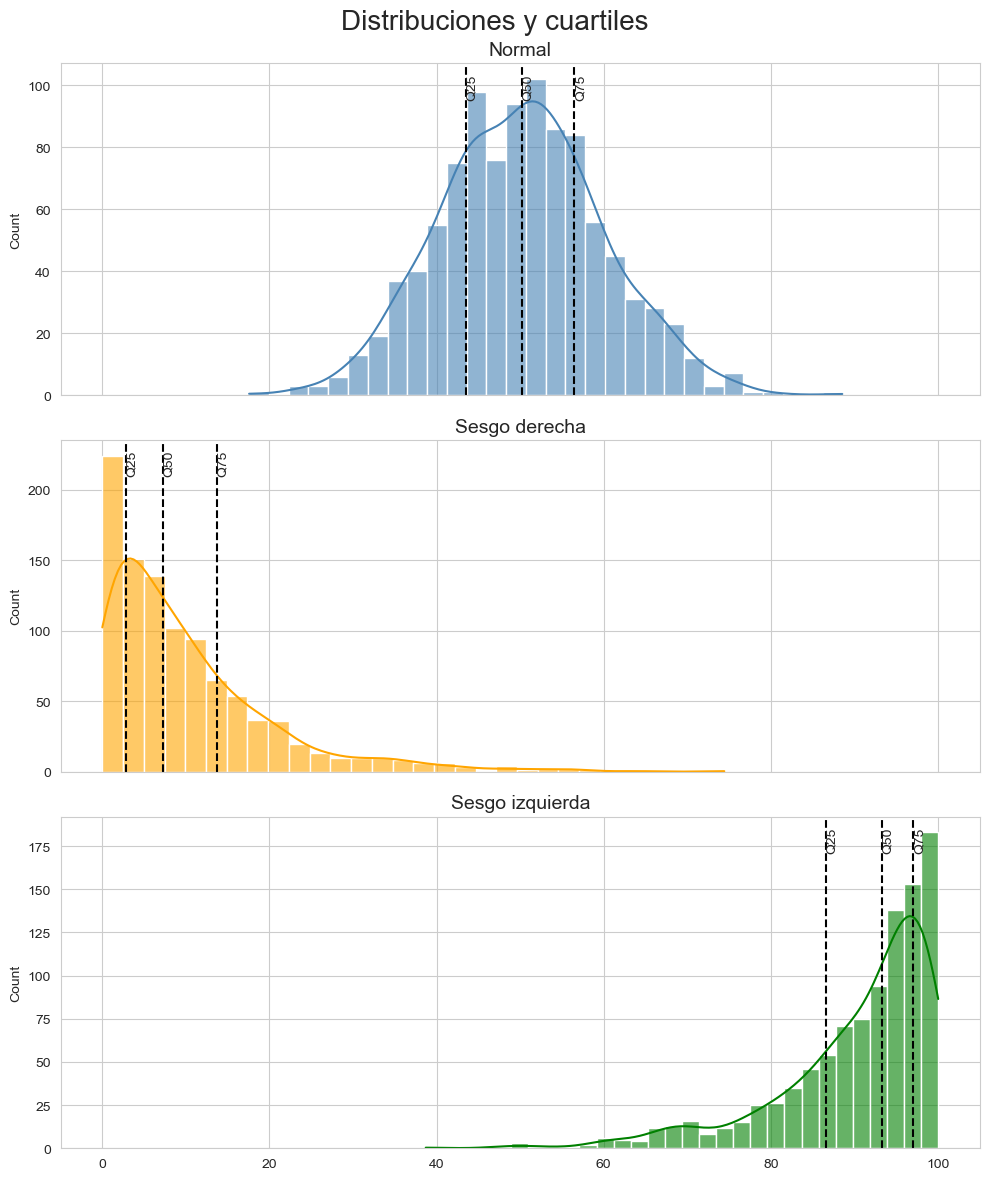

In [12]:
### Estilo seaborn
sns.set_style("whitegrid")

# Definimos el espacio de la Figura
fig, axes = plt.subplots(3,1,figsize=(10, 12), sharex=True)

### Graficar
for ax, (titulo, datos, color) in zip(axes, distribuciones):

    ### Graficamos el Histograma con KDE
    sns.histplot(datos, bins=30, kde=True, color=color, alpha=0.6,ax=ax)

    ### Calculamos los Cuartiles y los graficamos.
    for corte in cortes:
        q = np.quantile(datos, corte)
        ax.axvline(
            q,
            color="black",
            linestyle="--",
            linewidth=1.5
        )
        ax.text(
            q,
            ax.get_ylim()[1] * 0.9,
            f"Q{int(corte*100)}",
            rotation=90,
            fontsize=10
        )
    ax.set_title(titulo, fontsize=14)

plt.suptitle("Distribuciones y cuartiles",fontsize=20)
plt.tight_layout()
plt.show()

## Percentiles en Boxplot

* Este gráfico es importante, porque contiene:
  - Visualización de los datos.
  - Mediana.
  - IQR.
  - Outliers.
* ***¿Qué muestra un boxplot?***
* Representaba `la caja` que es desde el `Q1` hasta el `Q3`.
* La linea representaba la mediana.
* Los bigotes narcaban la extensión *“normal”* de los datos.
* Los puntos fuera, pues eran los `outliers`.
* Por ejemplo, un `boxplot` con su una caja muy baja y un bigote superior muy alto, indicaría ***datos sesgados hacia la derecha***.
  - Cola/bigote más largo hacia la derecha: `sesgo positivo`.
  - Cola/bigote más largo hacia la izquierda: `sesgo negativo`.

* La altura de las personas siguen una distribución normal.
* `loc=1.75` es la altura promedio de un ser humano con una desviación estándar de `0.15`.

In [16]:
import pandas as pd
### DataFrame para facilitar análisis
df = pd.DataFrame({
    "Normal": normal,
    "Sesgo derecha": sesgo_derecha,
    "Sesgo izquierda": sesgo_izquierda
})

### Cuartiles
print("\nCUARTILES\n")

for columna in df.columns:
    print(f"--- {columna} ---")
    print(df[columna].describe()[["min", "25%", "50%", "75%", "max"]])
    print()


CUARTILES

--- Normal ---
min    17.587327
25%    43.524097
50%    50.253006
75%    56.479439
max    88.527315
Name: Normal, dtype: float64

--- Sesgo derecha ---
min     0.032235
25%     2.839545
50%     7.259312
75%    13.716843
max    74.417229
Name: Sesgo derecha, dtype: float64

--- Sesgo izquierda ---
min    38.711770
25%    86.581860
50%    93.232950
75%    97.035787
max    99.999884
Name: Sesgo izquierda, dtype: float64



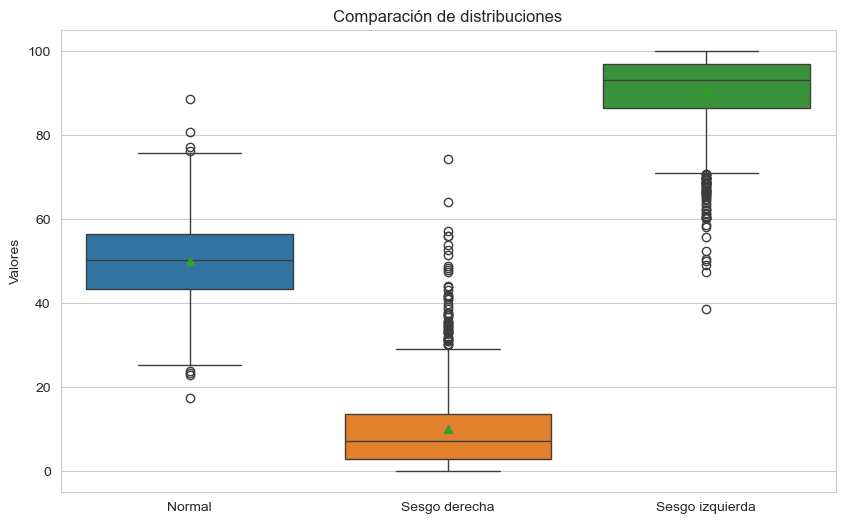

In [18]:
### Boxplots
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, showmeans=True)

# sns.stripplot(
#     data=df,
#     color="black",
#     alpha=0.2
# )

plt.title("Comparación de distribuciones")
plt.ylabel("Valores")

plt.show()

### Visualización de Cuantiles

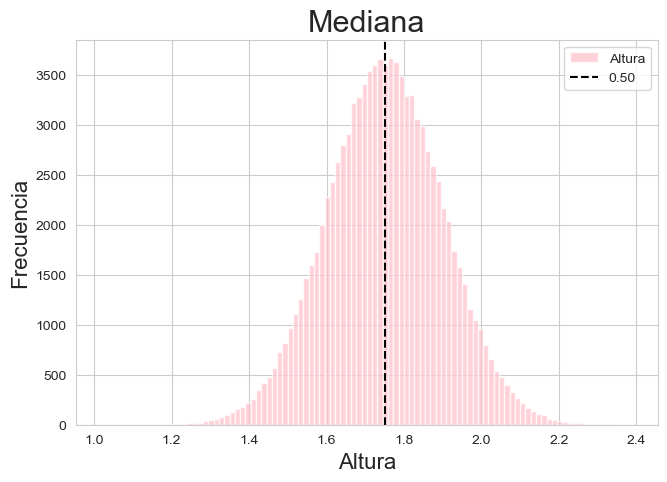

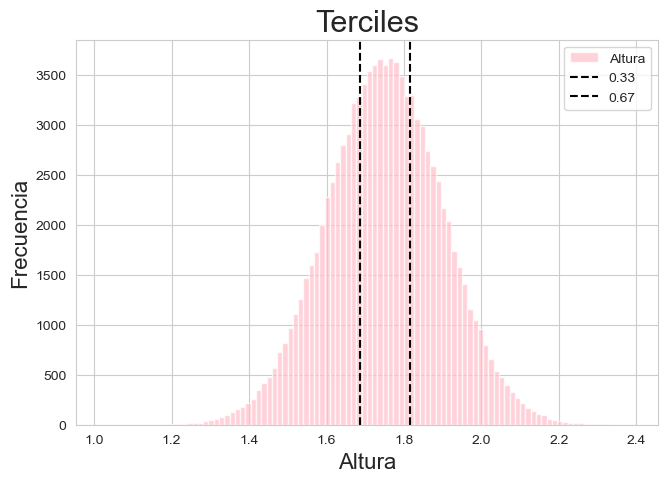

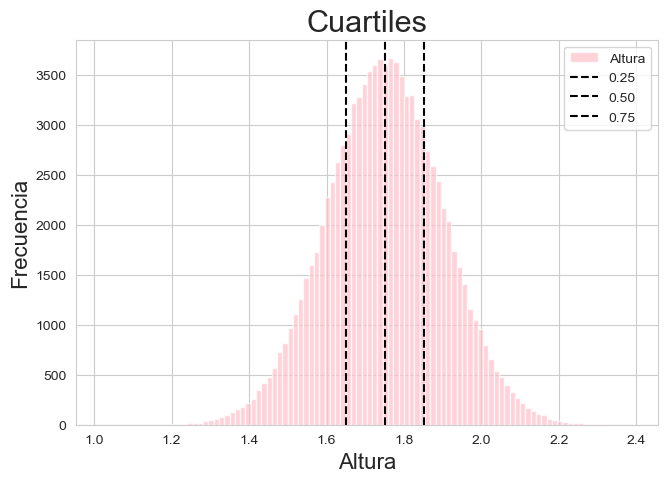

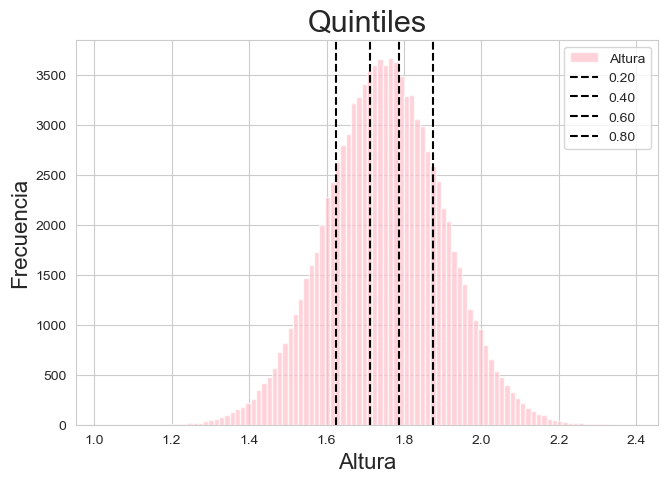

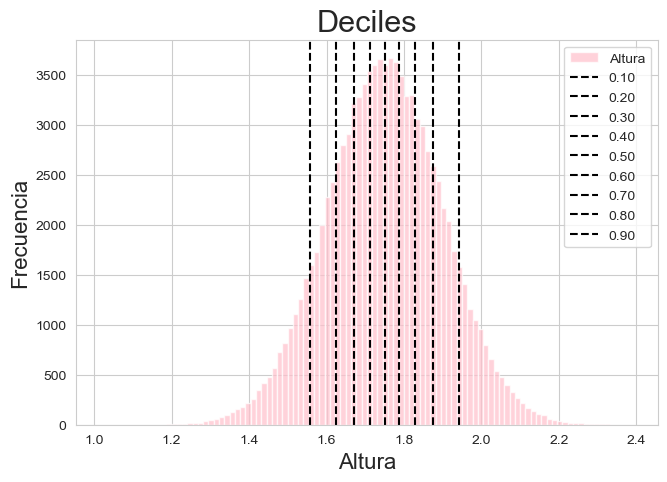

In [19]:
# Lista con todos los cuantiles
cuantiles = [
    (2, "Mediana"),
    (3, "Terciles"),
    (4, "Cuartiles"),
    (5, "Quintiles"),
    (10, "Deciles")
]
##,(100, "Percentiles")

cortes = []
for cuantil in cuantiles:
    corte = []
    valor = 0
    for i in range(cuantil[0]-1):
        valor += 1/cuantil[0]
        corte.append(valor)
    cortes.append(corte)

# Graficar los histogramas
for i in range(len(cuantiles)):
    plt.figure(figsize=(7.5,5))
    plt.title(cuantiles[i][1], size=22)
    plt.ylabel("Frecuencia", size=16)
    plt.xlabel("Altura", size=16)
    plt.hist(alturas, 100, label="Altura", color="pink", alpha=0.7)
    
    for corte in cortes[i]:
        plt.axvline(x=np.quantile(alturas, corte), label=f"{corte:.2f}", color="black", linestyle="--")
    plt.legend()
    plt.show()
    print("\n" * 4)


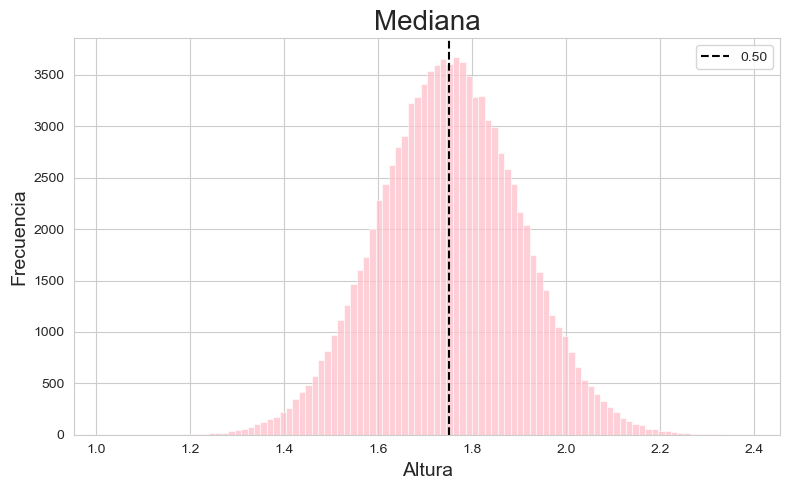

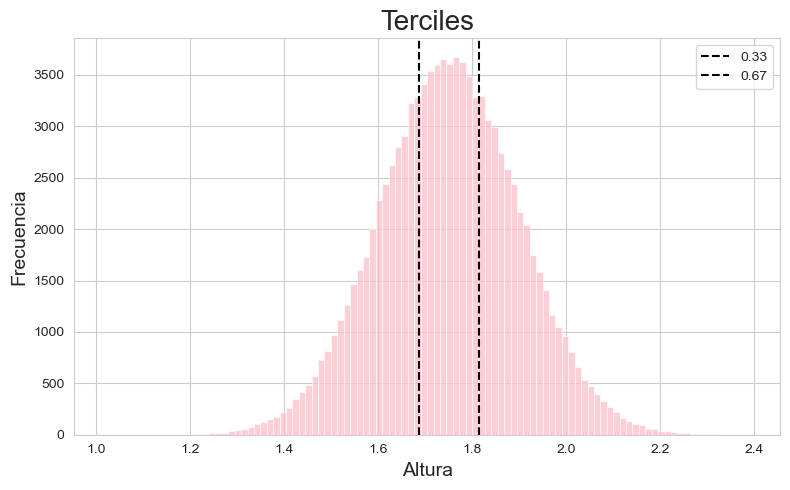

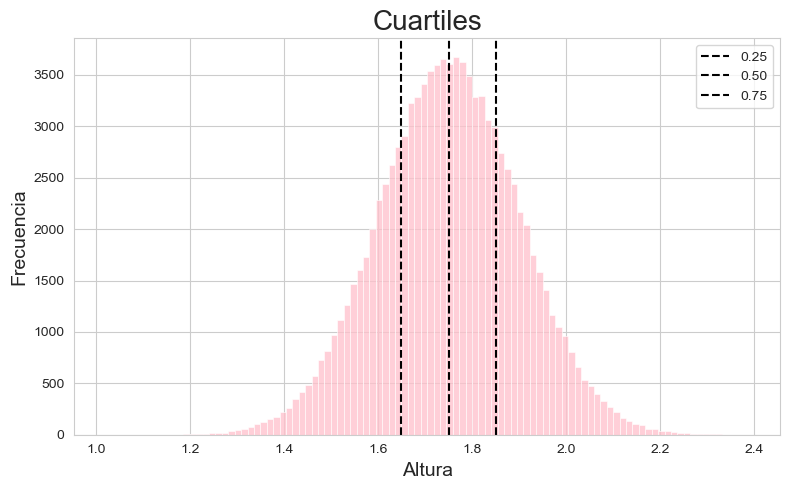

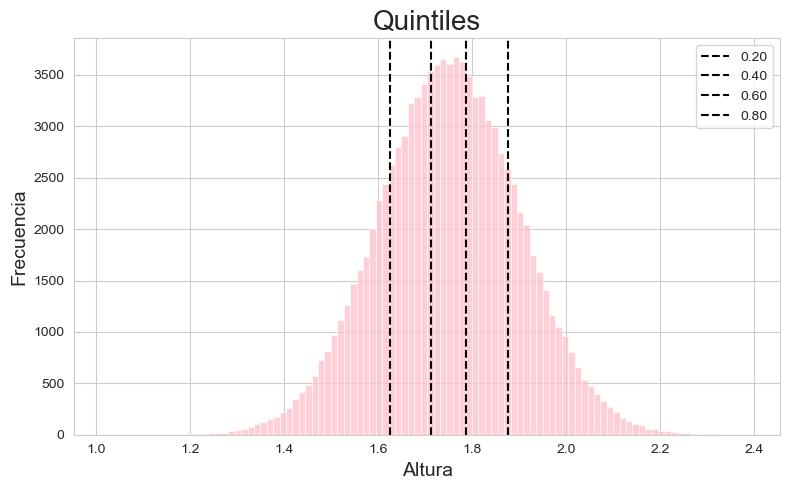

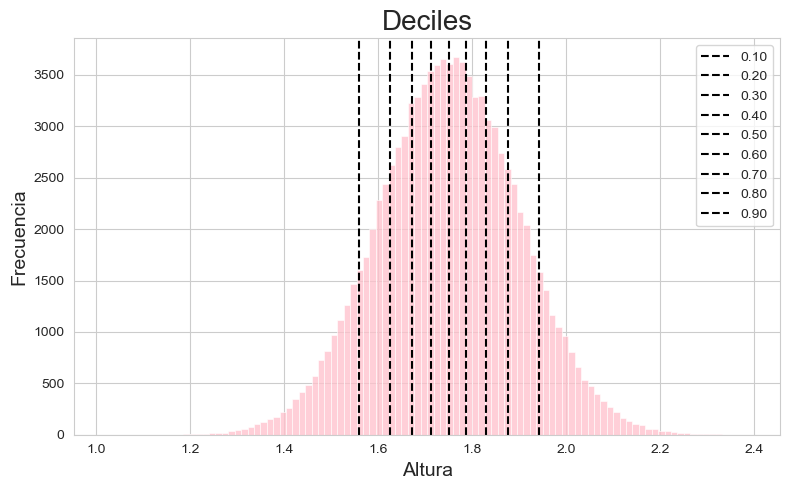

In [20]:
# Lista con los tipos de cuantiles
cuantiles = [
    (2, "Mediana"),
    (3, "Terciles"),
    (4, "Cuartiles"),
    (5, "Quintiles"),
    (10, "Deciles")
]
##(100, "Percentiles")

# Calcular los puntos de corte para cada tipo de cuantil
cortes = []
for cuantil in cuantiles:
    corte = []
    for i in range(1, cuantil[0]):
        corte.append(i / cuantil[0])
    cortes.append(corte)

# Graficar con Seaborn
for i in range(len(cuantiles)):
    plt.figure(figsize=(8, 5))
    sns.histplot(alturas, bins=100, color="pink", kde=False)
    #plt.yticks(np.arange(0,1001,50))
    plt.minorticks_on()
    for corte in cortes[i]:
        valor = np.quantile(alturas, corte)
        plt.axvline(valor, color="black", linestyle="--", label=f"{corte:.2f}")
    
    plt.title(cuantiles[i][1], fontsize=20)
    plt.xlabel("Altura", fontsize=14)
    plt.ylabel("Frecuencia", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("\n" * 3)